<a href="https://colab.research.google.com/github/paulocdvieira/FIAP-DA-F4-TC-GRUPO46/blob/main/f4_tc_pipeline_ml_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             roc_auc_score, classification_report, accuracy_score)

# 1. Abertura de dataset

In [2]:
# Chamando base obesity.csv do google drive

file_id = '1bmpE7oh-g2J9xQOSScrKL6byRzINCa2n'
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

# 2. EDA & Ajustes nos dados

In [3]:
df.shape

(2111, 17)

In [4]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity'],
      dtype='object')

In [5]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [7]:
df['Obesity'].value_counts().count()

np.int64(7)

In [8]:
df['Obesity'].value_counts()

,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [9]:
# Arredondamentos e Engenharia de Features inicial
cols_to_round = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in cols_to_round:
    df[col] = df[col].round(0).astype(int)



In [10]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
# Freq consumo alimentos caloricos

df['FCVC'].value_counts(normalize=True)*100

,proportion
FCVC,
2,47.986736
3,47.181431
1,4.831833


In [12]:
# Número refeições principais dia

df['NCP'].value_counts(normalize=True)*100

,proportion
NCP,
3,69.635244
1,14.969209
2,8.337281
4,7.058266


In [13]:
# Consumo de água

df['CH2O'].value_counts(normalize=True)*100

,proportion
CH2O,
2,52.581715
3,24.443392
1,22.974893


In [14]:
# Freq Semanal de atividades fisicas

df['FAF'].value_counts(normalize=True)*100

,proportion
FAF,
1,36.759829
0,34.107058
2,23.495973
3,5.637139


In [15]:
# Tempo usando eletronicos

df['TUE'].value_counts(normalize=True)*100

,proportion
TUE,
0,45.097110
1,43.344387
2,11.558503


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   int64  
 7   NCP             2111 non-null   int64  
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   int64  
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   int64  
 13  TUE             2111 non-null   int64  
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(3), int64(5), object(9

In [17]:
# Criando coluna IMC - Variavel importante para o resultados do modelo

df['IMC'] = df['Weight'] / (df['Height'] ** 2)

Como Calcular e Interpretar (Tabela IMC):

A fórmula é: IMC = Peso / (Altura × Altura).


*   Abaixo de 18,5: Abaixo do peso.
*   18,5 a 24,9: Peso Normal (ideal).
*   25,0 a 29,9: Sobrepeso (acima do peso).
*   30,0 ou mais: Obesidade..


In [18]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,IMC
0,Female,21.0,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [19]:
df['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
Male,50.592136
Female,49.407864


In [20]:
# Verificando quantas linhas são exatamente iguais
duplicados_total = df.duplicated().sum()
print(f"Total de linhas duplicadas: {duplicados_total}")

# Visualizando as primeiras linhas que se repetem para análise humana
if duplicados_total > 0:
    print("\nExemplo de linhas duplicadas:")
    print(df[df.duplicated(keep=False)].sort_values(by=['Age', 'Weight']).head(6))

Total de linhas duplicadas: 24

Exemplo de linhas duplicadas:
     Gender   Age  Height  Weight family_history FAVC  FCVC  NCP        CAEC  \
295  Female  16.0    1.66    58.0             no   no     2    1   Sometimes   
309  Female  16.0    1.66    58.0             no   no     2    1   Sometimes   
443    Male  18.0    1.72    53.0            yes  yes     2    3   Sometimes   
496    Male  18.0    1.72    53.0            yes  yes     2    3   Sometimes   
282  Female  18.0    1.62    55.0            yes  yes     2    3  Frequently   
460  Female  18.0    1.62    55.0            yes  yes     2    3  Frequently   

    SMOKE  CH2O SCC  FAF  TUE       CALC                 MTRANS  \
295    no     1  no    0    1         no                Walking   
309    no     1  no    0    1         no                Walking   
443    no     2  no    0    2  Sometimes  Public_Transportation   
496    no     2  no    0    2  Sometimes  Public_Transportation   
282    no     1  no    1    1         no  

# 3. EDA Gráficos

Análise da Variável Alvo (Obesity)

/tmp/ipython-input-2938134521.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Obesity', palette='viridis')


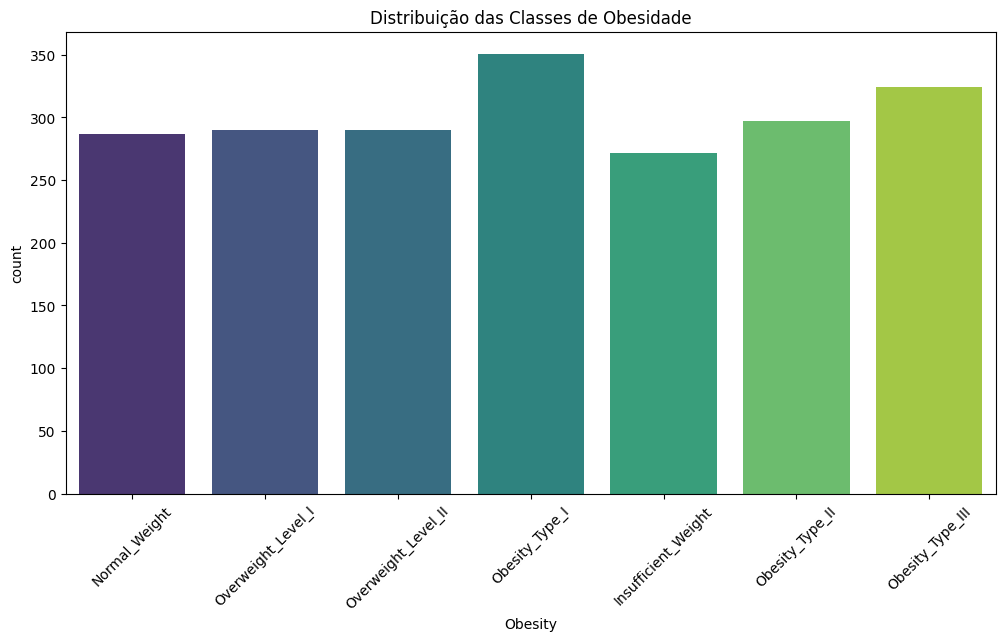

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Obesity', palette='viridis')
plt.xticks(rotation=45)
plt.title('Distribuição das Classes de Obesidade')
plt.show()

Análise das Colunas Individuais (Automatizada)

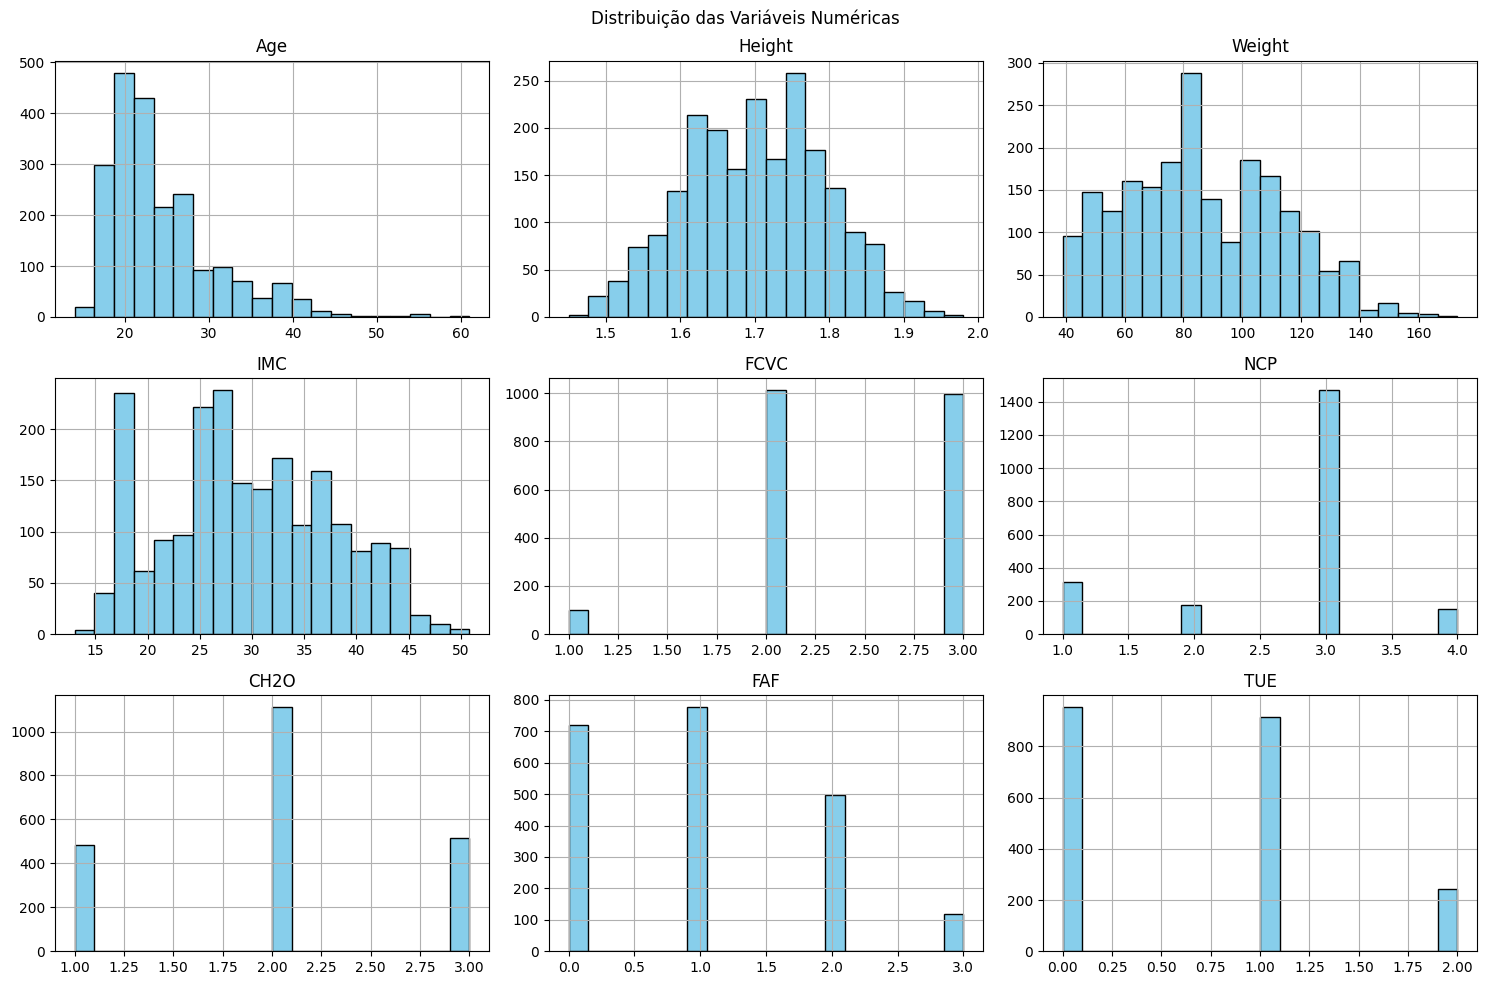

/tmp/ipython-input-984939692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='magma')
/tmp/ipython-input-984939692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='magma')
/tmp/ipython-input-984939692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='magma')
/tmp/ipython-input-984939692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` vari

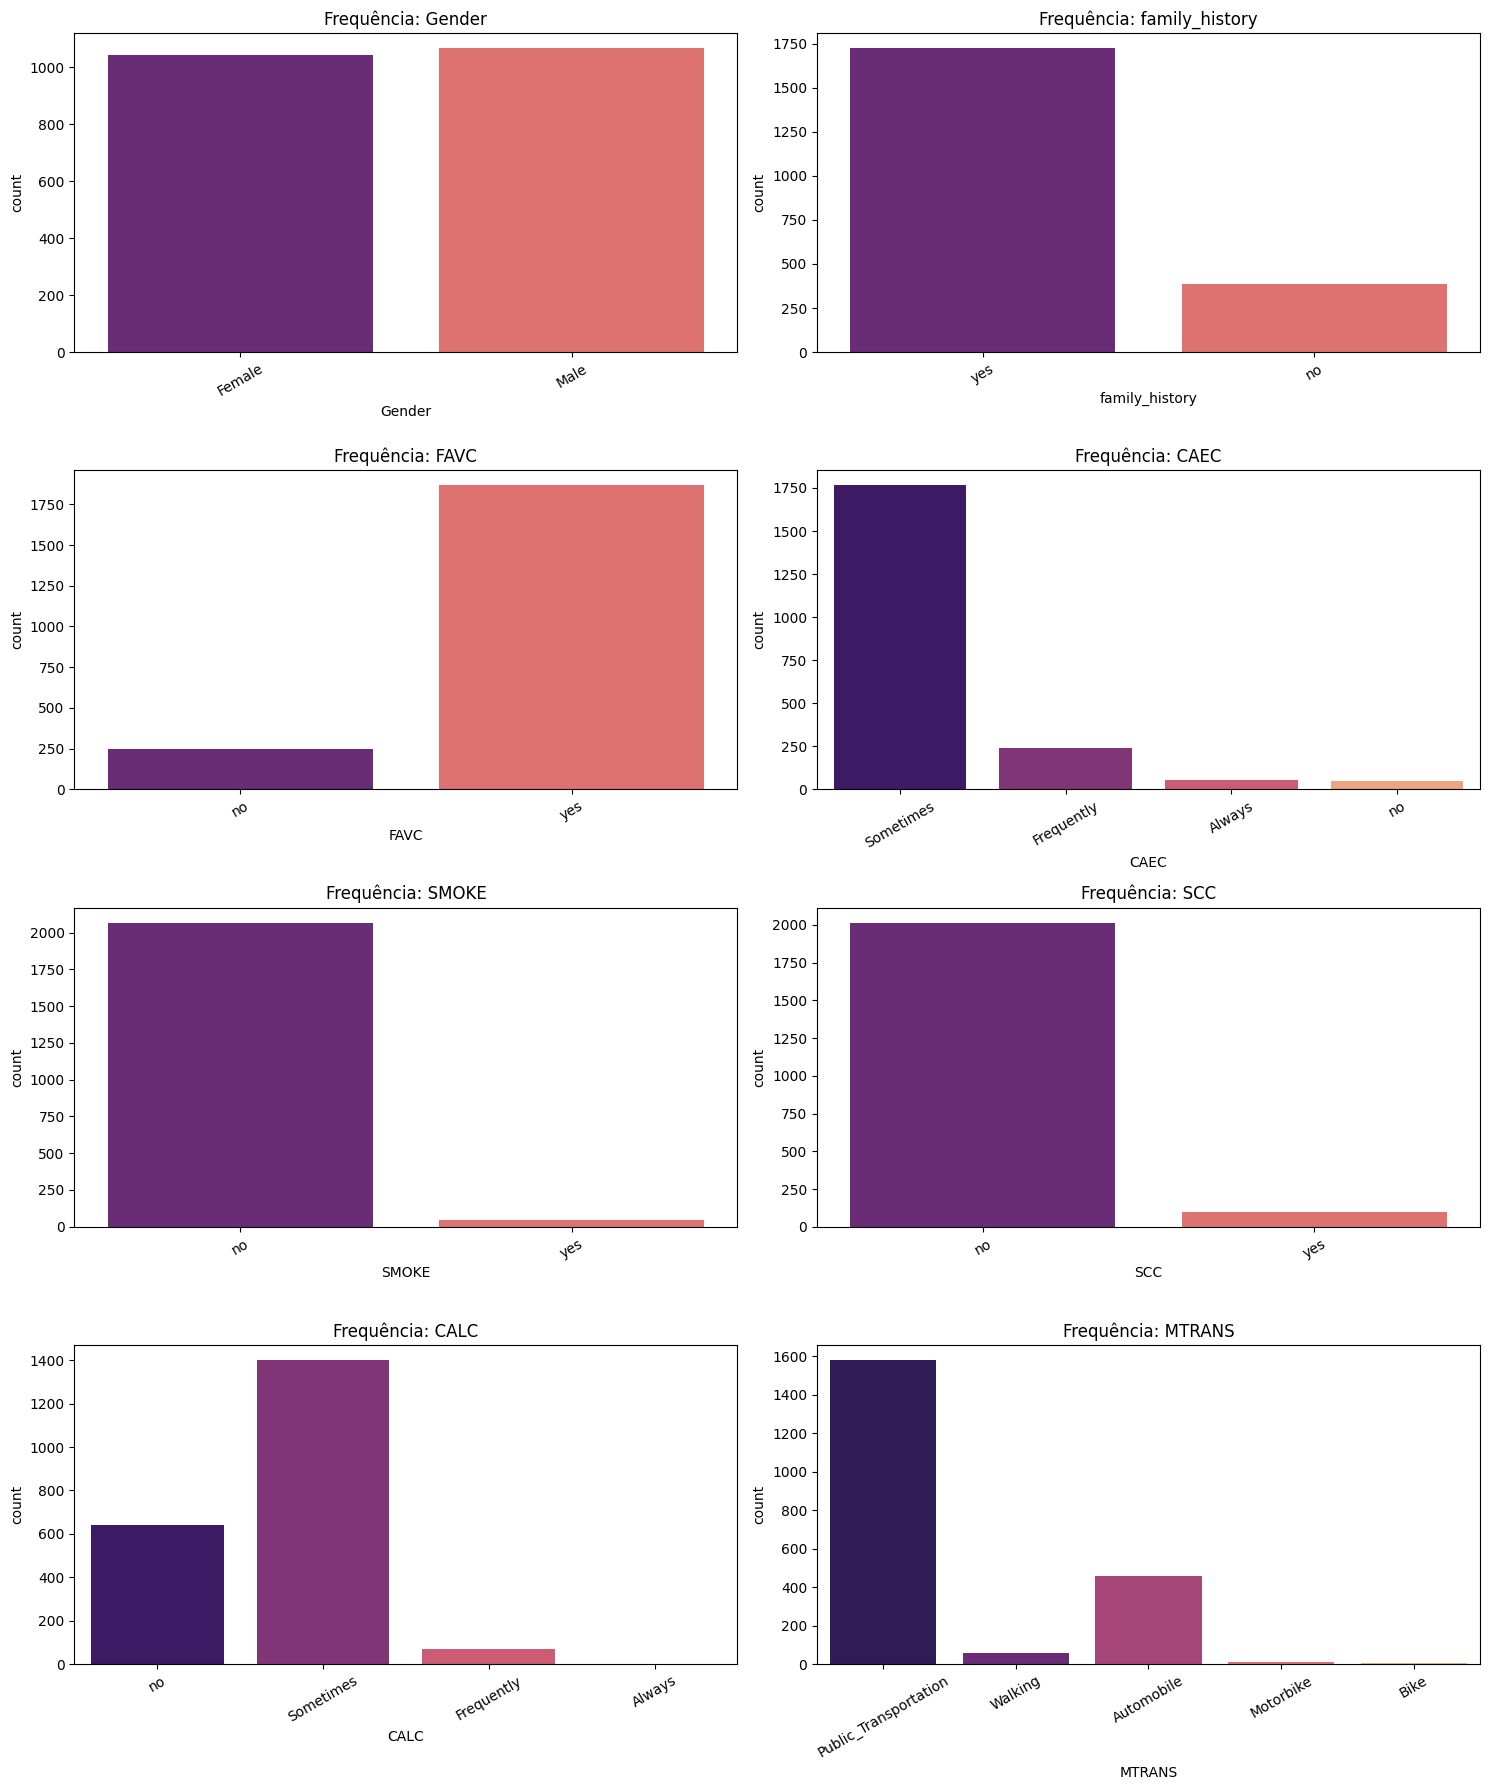

In [22]:
# Separando colunas por tipo
cols_numericas = ['Age', 'Height', 'Weight', 'IMC', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
cols_categoricas = ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# Gráficos para Variáveis Numéricas (Histogramas)
df[cols_numericas].hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.tight_layout()
plt.show()

# Gráficos para Variáveis Categóricas (Barras)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    sns.countplot(data=df, x=col, ax=axes[i], palette='magma')
    axes[i].set_title(f'Frequência: {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

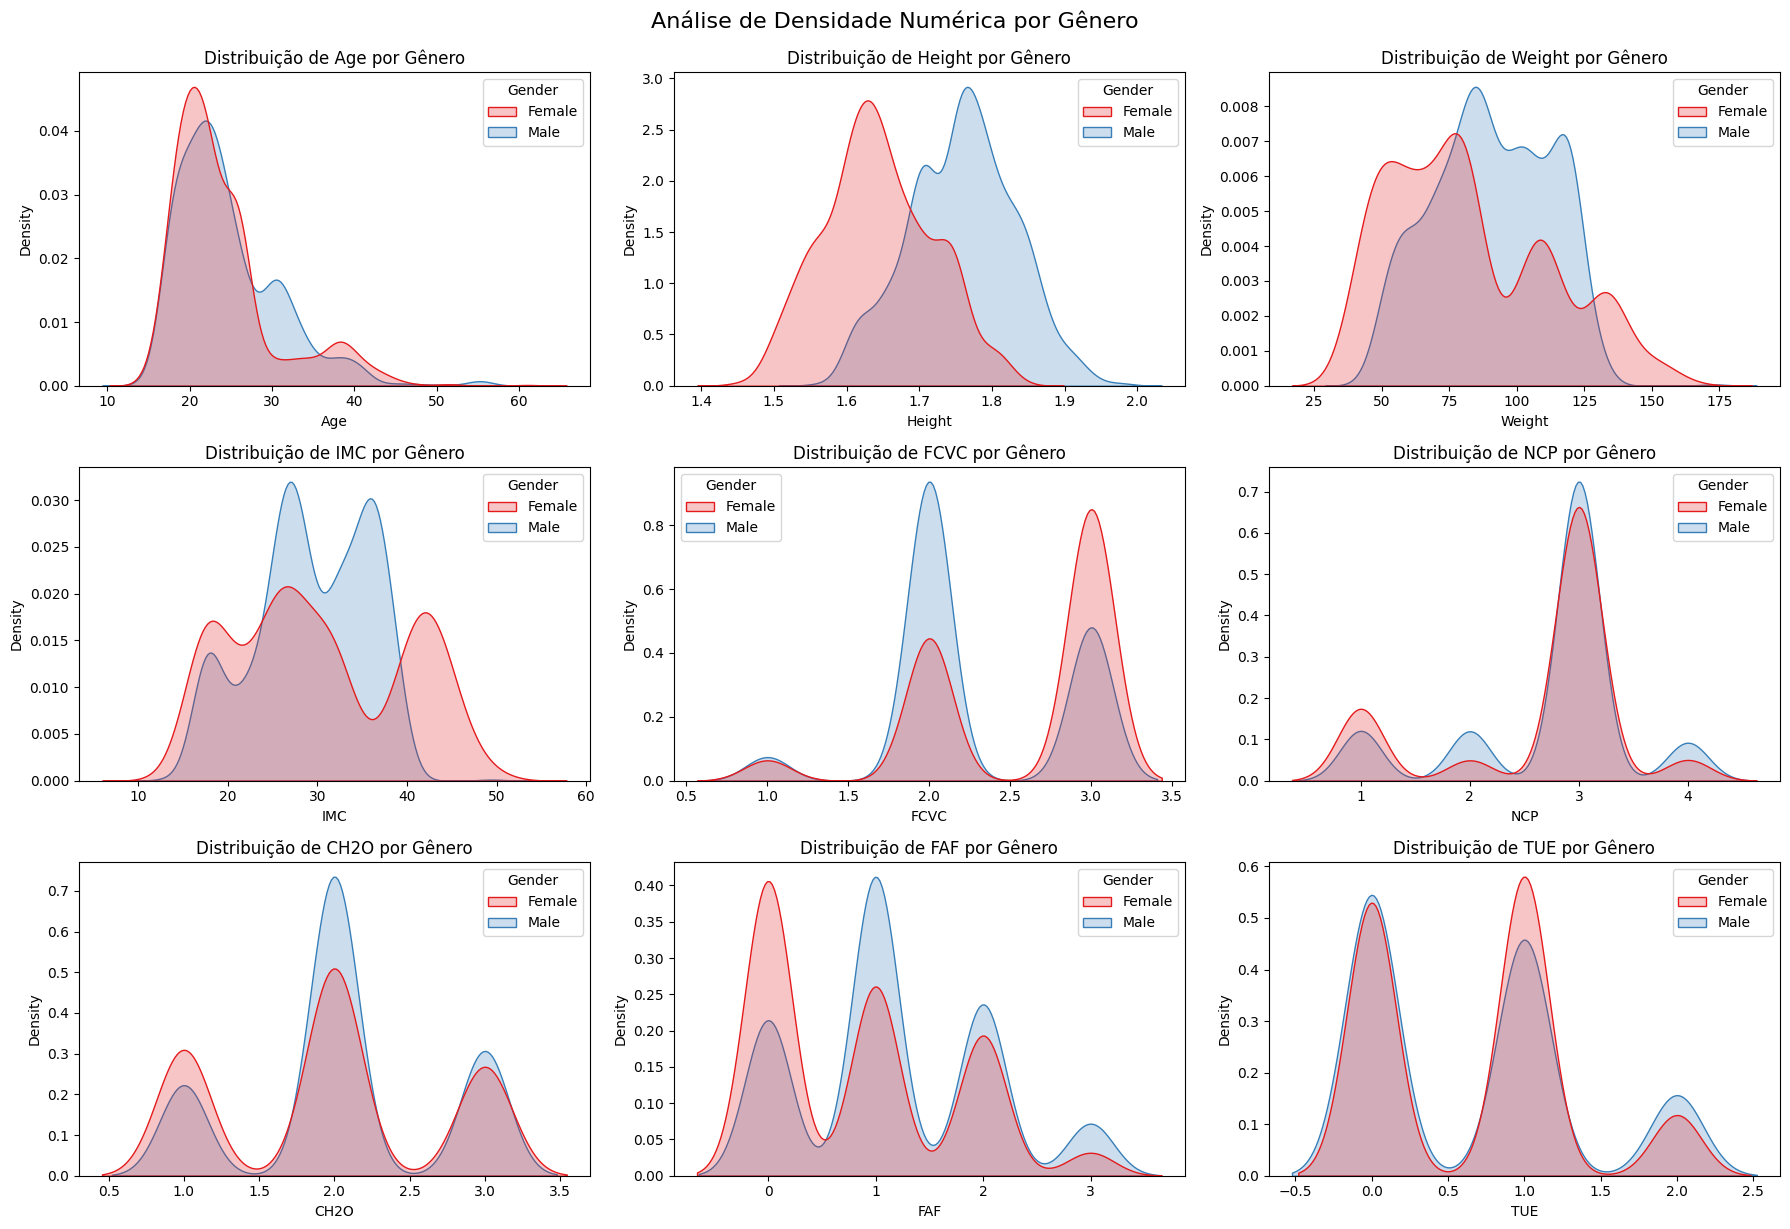

In [23]:
# Lista de colunas numéricas (incluindo o IMC que criamos)
cols_numericas = ['Age', 'Height', 'Weight', 'IMC', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Criando a grade de subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.kdeplot(data=df, x=col, hue='Gender', fill=True, ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribuição de {col} por Gênero')

plt.tight_layout()
plt.suptitle('Análise de Densidade Numérica por Gênero', y=1.02, fontsize=16)
plt.show()

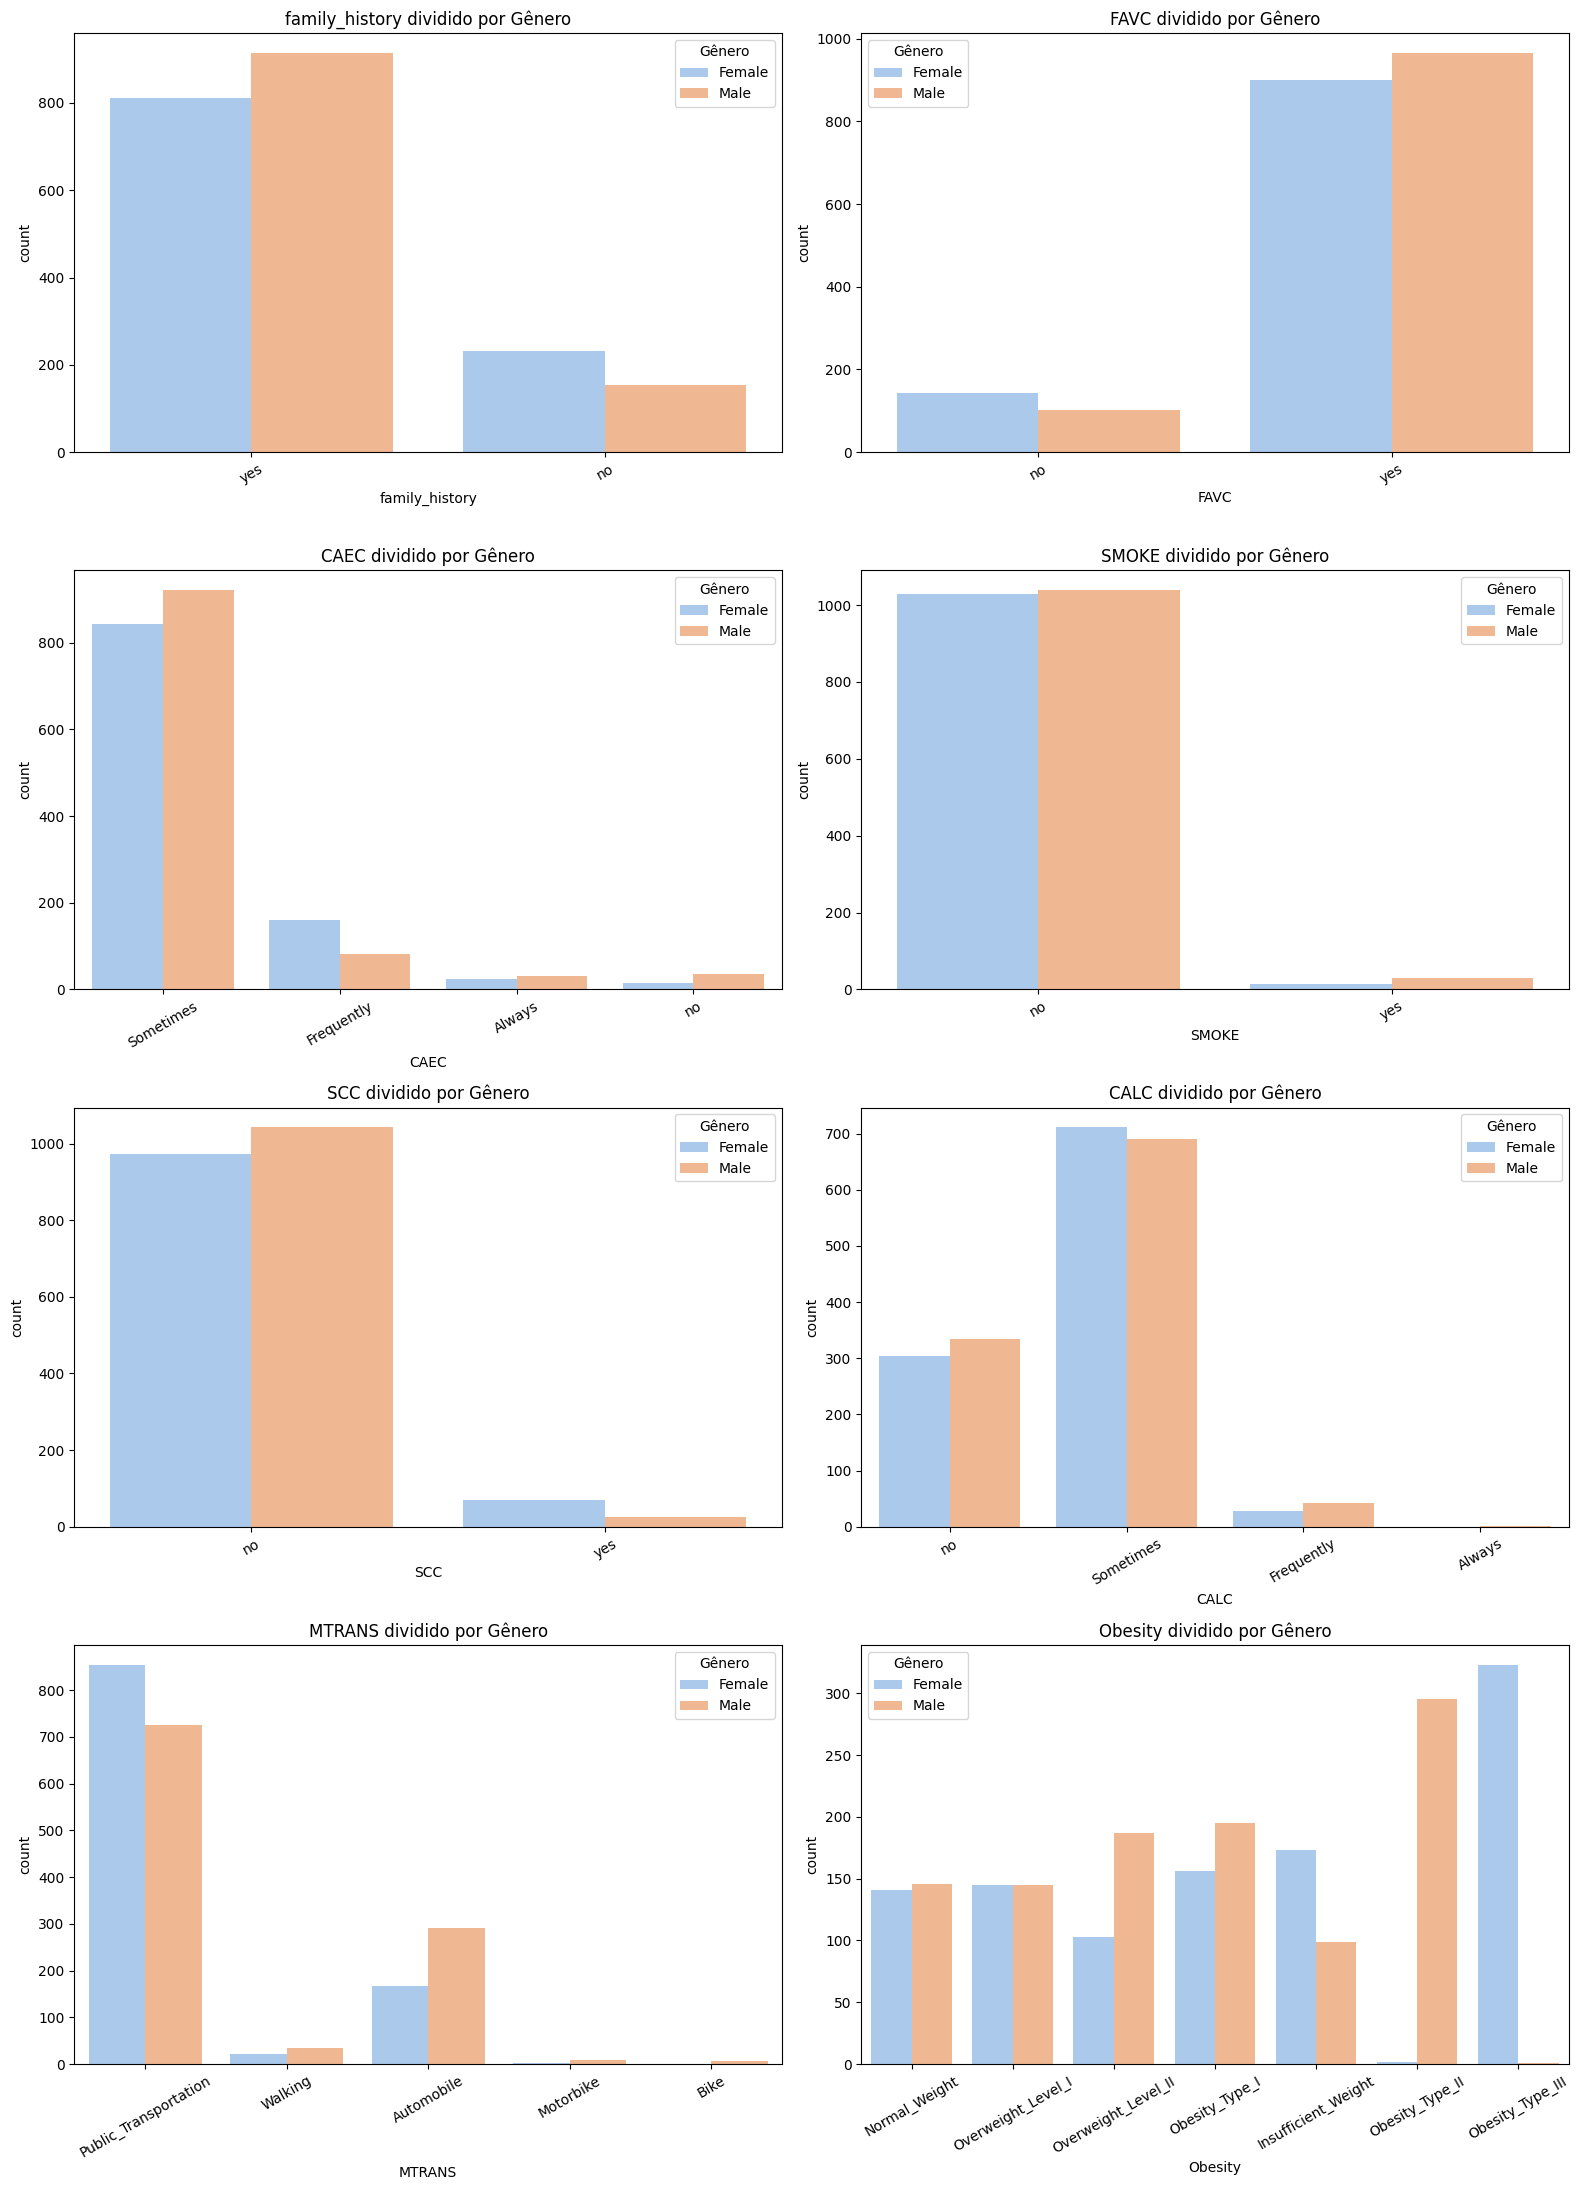

In [24]:
# Lista de colunas categóricas (removendo Gender da lista para o loop)
cols_categoricas_plot = ['family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'Obesity']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas_plot):
    sns.countplot(data=df, x=col, hue='Gender', ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} dividido por Gênero')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Gênero')

plt.tight_layout()
plt.show()

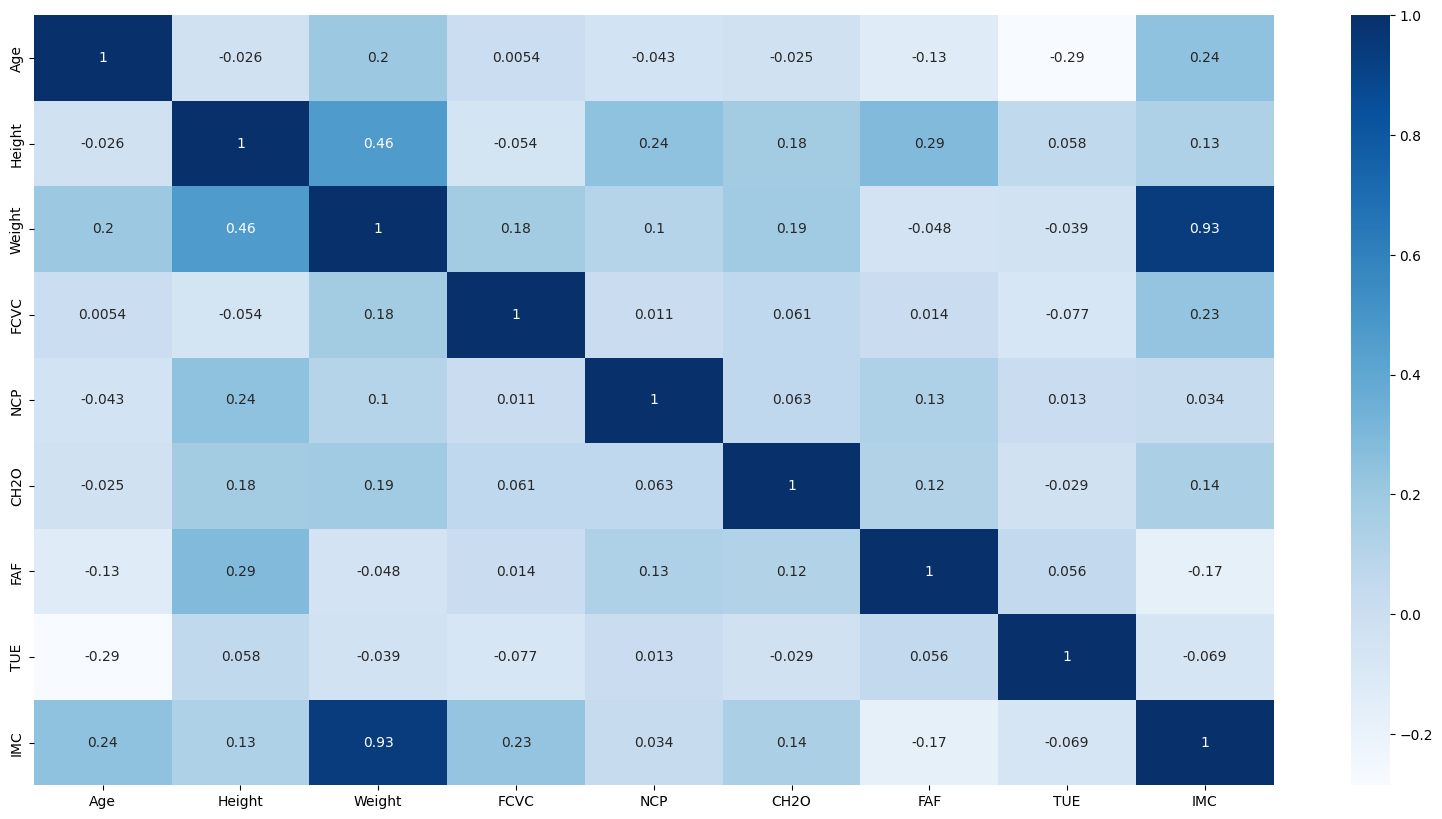

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize = (20,10))
sns.heatmap(corr, cmap="Blues", annot=True)
plt.show()

In [26]:
df.shape

(2111, 18)

In [27]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,IMC
0,Female,21.0,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   int64  
 7   NCP             2111 non-null   int64  
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   int64  
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   int64  
 13  TUE             2111 non-null   int64  
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
 17  IMC             2111 non-null   f

## Copia dataset original ajustado

In [29]:
df_copy = df

In [30]:
df_copy.to_csv('df_copy.csv')

# 4. Pipeline ML

## Classes de pré-processamento

In [31]:
class OrdinalFeature(BaseEstimator, TransformerMixin):
    def __init__(self, cols=['CAEC', 'CALC']):
        self.cols = cols
        self.mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
    def fit(self, X, y=None): return self
    def transform(self, X):
        X_copy = X.copy()
        for col in self.cols:
            X_copy[col] = X_copy[col].map(self.mapping).fillna(0)
        return X_copy

class ObesityEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.binary_mapping = {'no': 0, 'yes': 1}
        self.gender_mapping = {'Female': 0, 'Male': 1}
        self.oh_cols = ['MTRANS']
        self.encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    def fit(self, X, y=None):
        self.encoder.fit(X[self.oh_cols])
        return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['Gender'] = X_copy['Gender'].map(self.gender_mapping)
        for col in ['family_history', 'FAVC', 'SMOKE', 'SCC']:
            X_copy[col] = X_copy[col].map(self.binary_mapping)
        encoded = self.encoder.transform(X_copy[self.oh_cols])
        names = self.encoder.get_feature_names_out(self.oh_cols)
        df_encoded = pd.DataFrame(encoded, columns=names, index=X_copy.index)
        return pd.concat([X_copy.drop(columns=self.oh_cols), df_encoded], axis=1)

class MinMaxTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cols=['Age', 'Height', 'Weight', 'IMC']):
        self.cols = cols
        self.scaler = MinMaxScaler()
    def fit(self, X, y=None):
        self.scaler.fit(X[self.cols])
        return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.cols] = self.scaler.transform(X_copy[self.cols])
        return X_copy

## Função mestra de execução de modelos ML

In [32]:
def roda_modelo(modelo_bruto):
    """
    Cria a pipeline, treina e gera todas as avaliações multiclasse com nomes originais.
    """
    # Criamos a pipeline com as transformações e o modelo escolhido
    pipeline_completa = Pipeline([
        ('ord', OrdinalFeature()),
        ('cat', ObesityEncoder()),
        ('mms', MinMaxTransformer()),
        ('model', modelo_bruto)
    ])

    # Treinamento (usa os dados globais X_train e y_train)
    pipeline_completa.fit(X_train, y_train)

    # Predições
    predicao = pipeline_completa.predict(X_test)
    prob_predic = pipeline_completa.predict_proba(X_test)

    # Nome do modelo para o print
    nome_modelo = type(modelo_bruto).__name__

    # AUC Multiclasse (Weighted One-vs-Rest)
    auc_val = roc_auc_score(y_test, prob_predic, multi_class='ovr', average='weighted')

    print(f"\n{'='*20} RESULTS: {nome_modelo} {'='*20}")
    print(f"AUC (Weighted OvR): {auc_val:.4f}")
    print(f"Accuracy: {accuracy_score(y_test, predicao):.4f}")

    # Labels originais (sem tradução)
    labels_obesidade = [
        'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
        'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
    ]

    # --- 1. Matriz de Confusão (Acertos Absolutos) ---
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_estimator(
        pipeline_completa, X_test, y_test,
        display_labels=labels_obesidade, ax=ax, cmap=plt.cm.Greens
    )
    ax.set_title(f"Confusion Matrix (Absolute Values)\n{nome_modelo}", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

    # --- 2. Matriz de Confusão (Percentual de Acertos/Normalizada) ---
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_estimator(
        pipeline_completa, X_test, y_test, normalize='true',
        display_labels=labels_obesidade, ax=ax, cmap=plt.cm.Blues
    )
    ax.set_title(f"Normalized Confusion Matrix (Percentage)\n{nome_modelo}", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

    # --- 3. Curva ROC (Uma para cada classe) ---
    print(f"Generating ROC Curve for {nome_modelo}...")
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(len(labels_obesidade)):
        RocCurveDisplay.from_predictions(
            (y_test == i).astype(int), prob_predic[:, i],
            name=f"{labels_obesidade[i]}", ax=ax
        )
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title(f"ROC Curves by Class - {nome_modelo}")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, predicao, target_names=labels_obesidade, zero_division=0))

    return pipeline_completa

## Preparação de dados e divisão (Treino & Teste)

In [33]:
# X com dados brutos (sem dummies ou maps manuais)
X = df.drop(columns=['Obesity'])

# Mapeamento da variável alvo (Target)
target_map = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
y = df['Obesity'].map(target_map)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelo Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

Random Forest


==================== RESULTS: RandomForestClassifier ====================
AUC (Weighted OvR): 0.9999
Accuracy: 0.9905


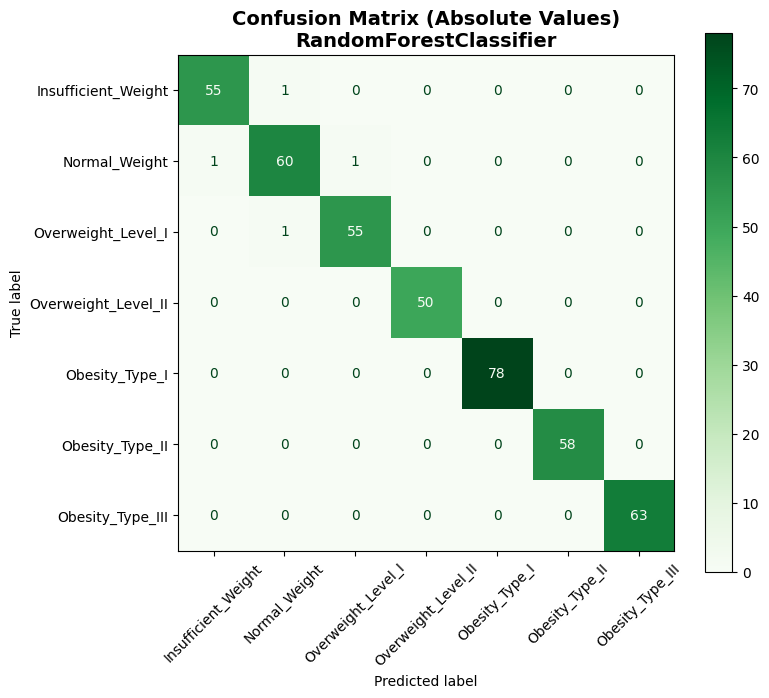

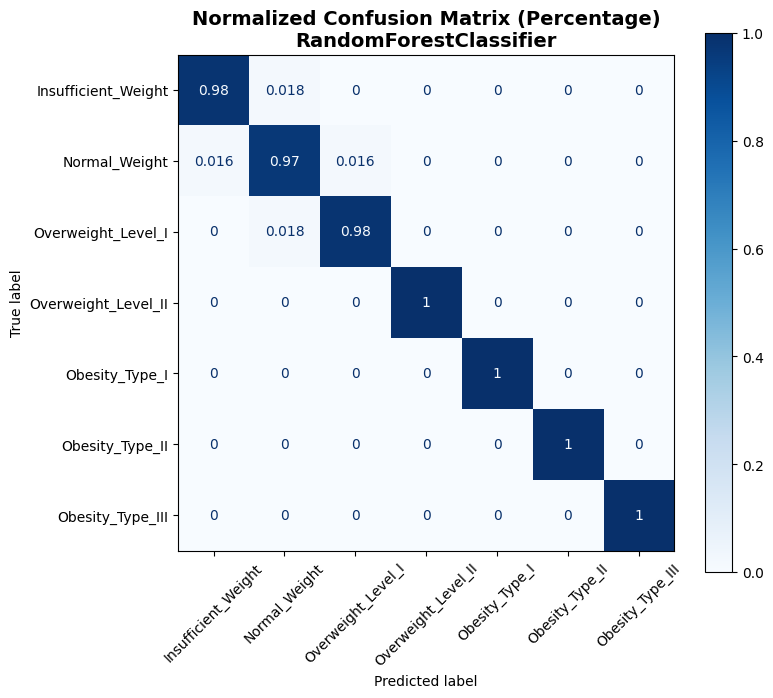

Generating ROC Curve for RandomForestClassifier...


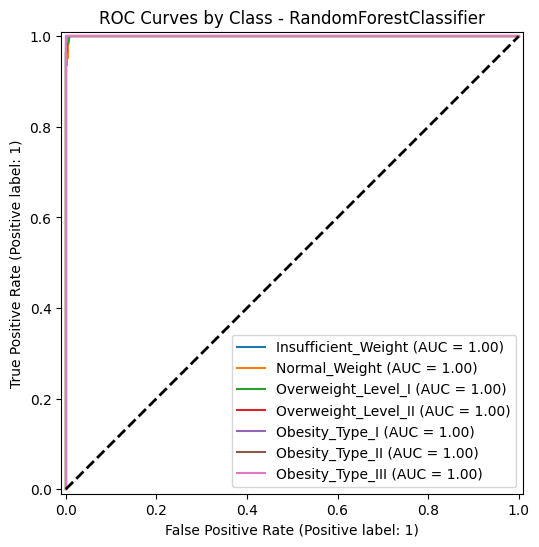


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        56
      Normal_Weight       0.97      0.97      0.97        62
 Overweight_Level_I       0.98      0.98      0.98        56
Overweight_Level_II       1.00      1.00      1.00        50
     Obesity_Type_I       1.00      1.00      1.00        78
    Obesity_Type_II       1.00      1.00      1.00        58
   Obesity_Type_III       1.00      1.00      1.00        63

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



In [35]:
modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42)
pipeline_rf = roda_modelo(modelo_forest)

## Modelo XGB

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:33:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==================== RESULTS: XGBClassifier ====================
AUC (Weighted OvR): 0.9997
Accuracy: 0.9882


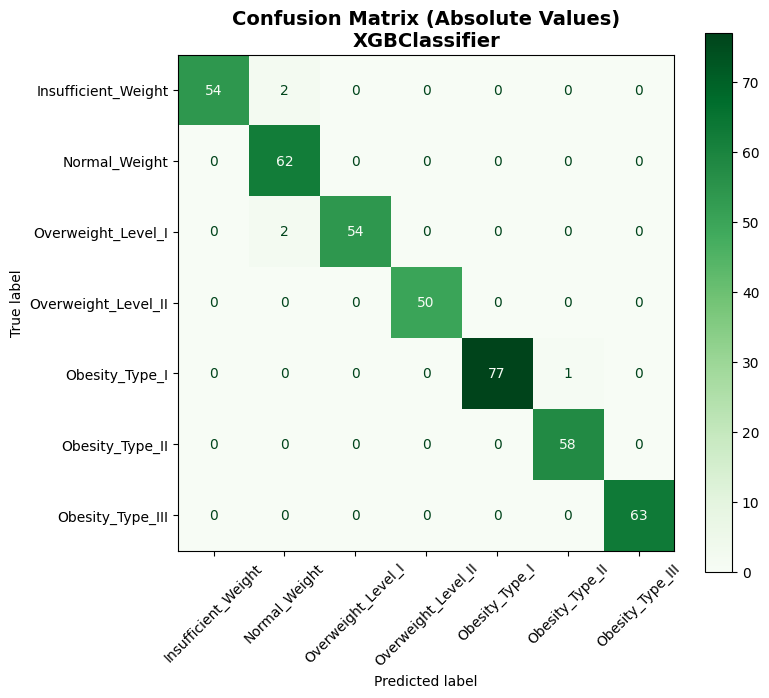

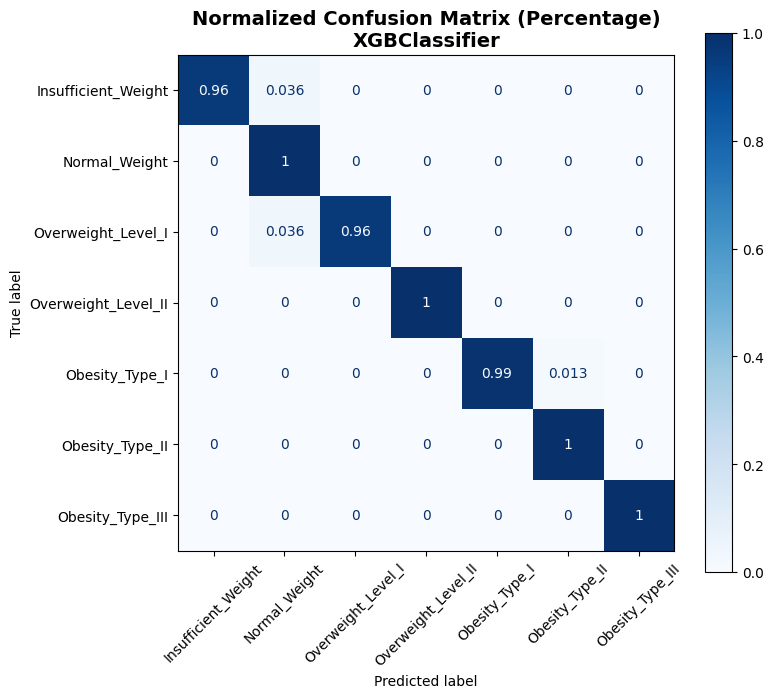

Generating ROC Curve for XGBClassifier...


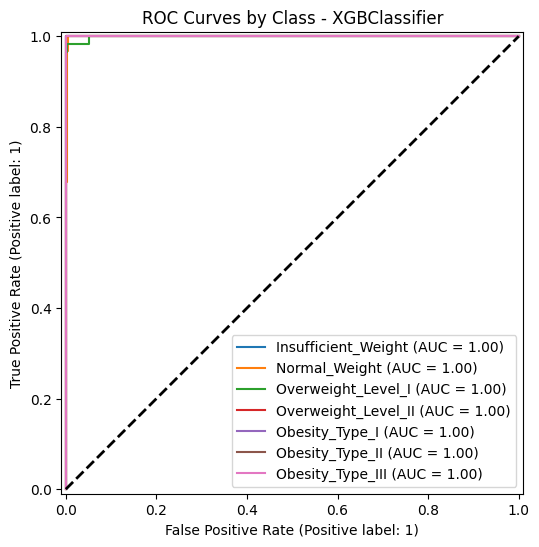


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        56
      Normal_Weight       0.94      1.00      0.97        62
 Overweight_Level_I       1.00      0.96      0.98        56
Overweight_Level_II       1.00      1.00      1.00        50
     Obesity_Type_I       1.00      0.99      0.99        78
    Obesity_Type_II       0.98      1.00      0.99        58
   Obesity_Type_III       1.00      1.00      1.00        63

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



In [36]:
modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
pipeline_xgb = roda_modelo(modelo_xgb)

## Modelo SVM


==================== RESULTS: SVC ====================
AUC (Weighted OvR): 0.9615
Accuracy: 0.7494


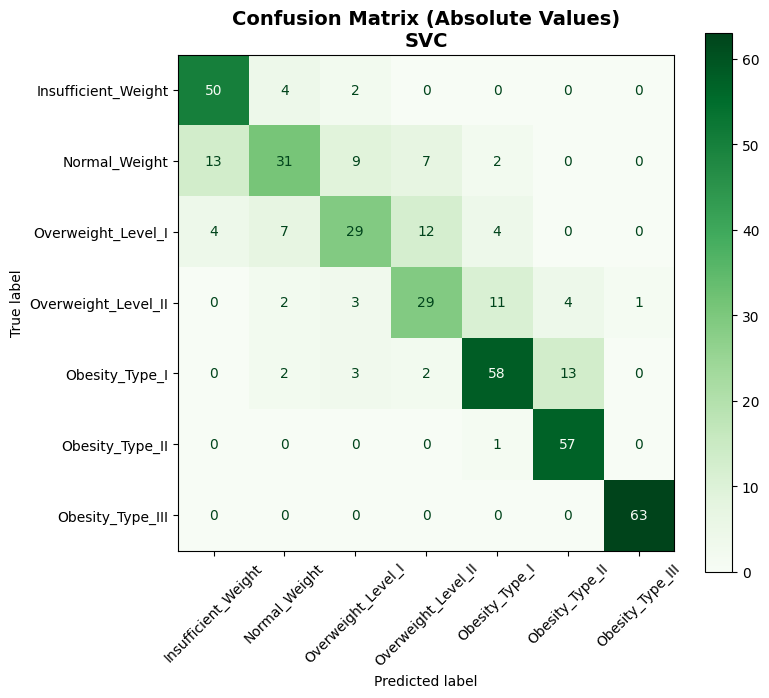

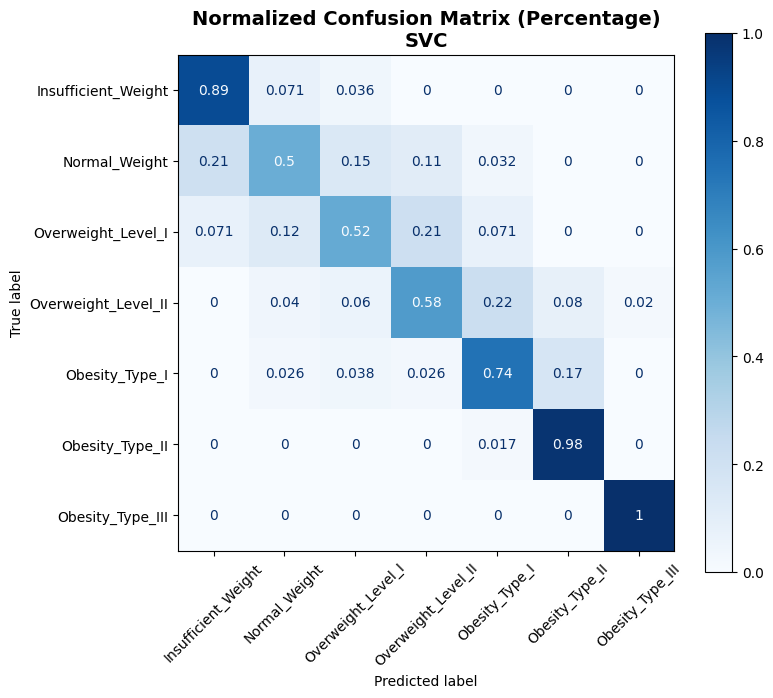

Generating ROC Curve for SVC...


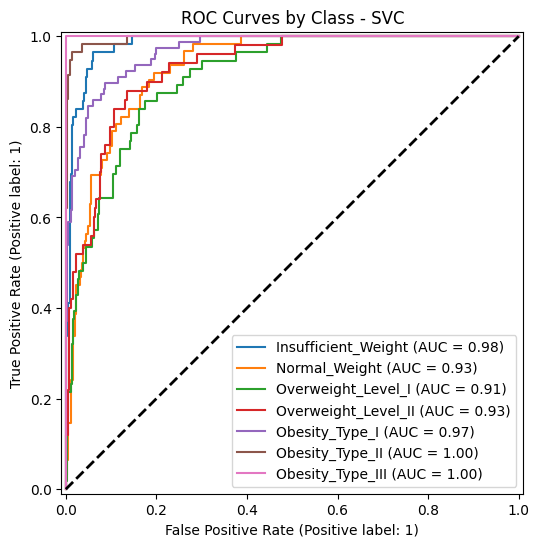


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.75      0.89      0.81        56
      Normal_Weight       0.67      0.50      0.57        62
 Overweight_Level_I       0.63      0.52      0.57        56
Overweight_Level_II       0.58      0.58      0.58        50
     Obesity_Type_I       0.76      0.74      0.75        78
    Obesity_Type_II       0.77      0.98      0.86        58
   Obesity_Type_III       0.98      1.00      0.99        63

           accuracy                           0.75       423
          macro avg       0.74      0.75      0.73       423
       weighted avg       0.74      0.75      0.74       423



In [37]:
modelo_svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
pipeline_svm = roda_modelo(modelo_svm)

#  5. Avaliação Final


      TABELA COMPARATIVA DE PERFORMANCE FINAL
        Model Accuracy    AUC
Random Forest   0.9905 0.9999
      XGBoost   0.9882 0.9997
          SVM   0.7494 0.9615


/tmp/ipython-input-499253472.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis', ax=ax1)
/tmp/ipython-input-499253472.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC', y='Model', data=df_auc_sorted, palette='magma', ax=ax2)


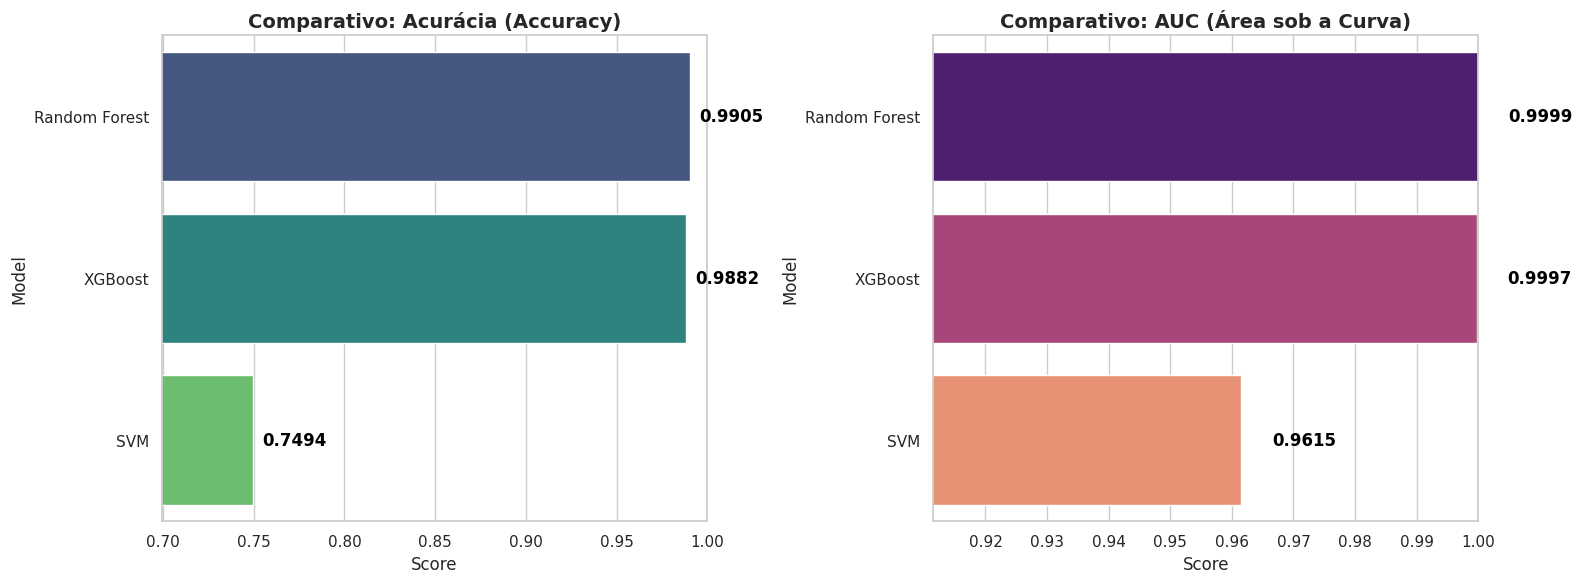

In [38]:
"""# Final Evaluation: Comparative Tables and Charts (Accuracy vs AUC)"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Função para Extração de Métricas
# Esta função garante que o cálculo seja idêntico para todos os modelos
def extrair_metricas(pipeline, X_test, y_test):
    # Predições de classe e de probabilidade
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    # Cálculo da Acurácia
    acc = accuracy_score(y_test, y_pred)

    # Cálculo do AUC Multiclasse (Weighted OvR)
    # Estratégia 'weighted' pondera o resultado pelo número de instâncias de cada classe
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    return acc, auc

# 2. Consolidação dos resultados das pipelines treinadas
# Nota: Certifique-se de que as variáveis pipeline_rf, pipeline_xgb e pipeline_svm existam
try:
    acc_rf, auc_rf = extrair_metricas(pipeline_rf, X_test, y_test)
    acc_xgb, auc_xgb = extrair_metricas(pipeline_xgb, X_test, y_test)
    acc_svm, auc_svm = extrair_metricas(pipeline_svm, X_test, y_test)

    # 3. Criação do DataFrame Comparativo
    data = {
        'Model': ['Random Forest', 'XGBoost', 'SVM'],
        'Accuracy': [acc_rf, acc_xgb, acc_svm],
        'AUC': [auc_rf, auc_xgb, auc_svm]
    }

    df_results = pd.DataFrame(data).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

    # 4. Exibição da Tabela Comparativa (Formatação Profissional)
    print("\n" + "="*50)
    print("      TABELA COMPARATIVA DE PERFORMANCE FINAL")
    print("="*50)
    # Formatadores garantem 4 casas decimais para precisão técnica
    print(df_results.to_string(index=False, formatters={'Accuracy': '{:.4f}'.format, 'AUC': '{:.4f}'.format}))
    print("="*50)

    # 5. Geração dos Gráficos Comparativos (Lado a Lado)
    sns.set_theme(style="whitegrid") # Estilo mais limpo para apresentação
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Subplot 1: Acurácia ---
    sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis', ax=ax1)
    ax1.set_title('Comparativo: Acurácia (Accuracy)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Score')
    # Ajuste de zoom no eixo X para evidenciar a diferença entre modelos de alta performance
    min_acc = df_results['Accuracy'].min()
    ax1.set_xlim(max(0, min_acc - 0.05), 1.0)

    for i, v in enumerate(df_results['Accuracy']):
        ax1.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', color='black')

    # --- Subplot 2: AUC ---
    # Reordenamos por AUC para manter a hierarquia visual correta no segundo gráfico
    df_auc_sorted = df_results.sort_values(by='AUC', ascending=False)
    sns.barplot(x='AUC', y='Model', data=df_auc_sorted, palette='magma', ax=ax2)
    ax2.set_title('Comparativo: AUC (Área sob a Curva)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Score')
    min_auc = df_results['AUC'].min()
    ax2.set_xlim(max(0, min_auc - 0.05), 1.0)

    for i, v in enumerate(df_auc_sorted['AUC']):
        ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"Erro: Certifique-se de que todas as pipelines foram treinadas e salvas corretamente. {e}")

# Equilibrio das Classes de Obesidade

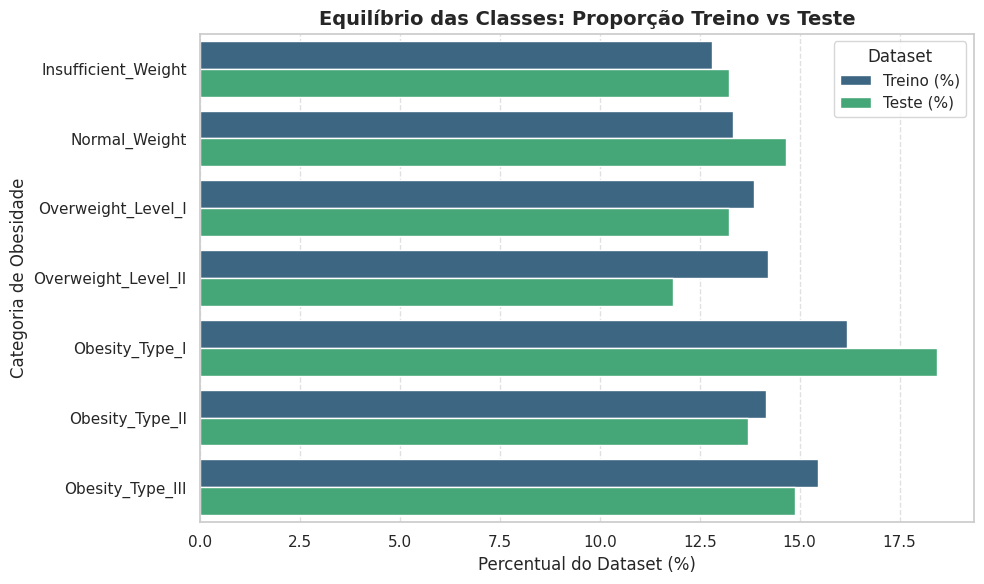

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir os nomes das classes (Labels) que faltaram no escopo global
labels_obesidade = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

# 2. Calcular a distribuição percentual
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

# 3. Organizar os dados para o gráfico
df_dist = pd.DataFrame({
    'Classe': [labels_obesidade[i] for i in train_dist.index],
    'Treino (%)': train_dist.values * 100,
    'Teste (%)': test_dist.values * 100
}).melt(id_vars='Classe', var_name='Conjunto', value_name='Percentual')

# 4. Exibir o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dist, x='Percentual', y='Classe', hue='Conjunto', palette='viridis')

plt.title('Equilíbrio das Classes: Proporção Treino vs Teste', fontsize=14, fontweight='bold')
plt.xlabel('Percentual do Dataset (%)')
plt.ylabel('Categoria de Obesidade')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Dataset')

plt.tight_layout()
plt.show()

# Salvando o Modelo Random Forest

In [41]:
import joblib

# Este comando cria o arquivo físico na pasta do seu ambiente
joblib.dump(X_train.columns.tolist(), 'colunas_modelo.joblib')

print("Arquivo 'colunas_modelo.joblib' criado com sucesso!")

Arquivo 'colunas_modelo.joblib' criado com sucesso!


In [40]:
import joblib

# Salvando a pipeline completa do Random Forest
joblib.dump(pipeline_rf, 'modelo_obesidade_rf.joblib')

print("Modelo exportado com sucesso! Procure pelo arquivo 'modelo_obesidade_rf.joblib' na sua pasta.")

Modelo exportado com sucesso! Procure pelo arquivo 'modelo_obesidade_rf.joblib' na sua pasta.


Fim